<a href="https://colab.research.google.com/github/MuriloTM7/Avancando-em-Data-Science-com-Python/blob/Estudos-Python/Predi%C3%A7%C3%A3o_do_pre%C3%A7o_de_imoveis_ALURA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preço de imoveis

**Objetivo**: estimar os preços de imóveis
 * Identificar aspectos que contribuem para precificação dos imoveis
 * Entender qual aspecto é mais relevante, qual influencia mais no preço do imóvel.
 * Precificar um imóvel novo.

Base de dados simplificada e inspirada em [House Prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)



![](https://i.imgur.com/A8X79yq.jpeg)


# 1. Ajustando uma reta

## Conhecendo os dados

In [2]:
import pandas as pd
#Lendo dados
dados = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science/Dados/Dados regressão linear/Preços_de_casas.csv')

In [3]:
#Quais fatores coletados?

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [4]:
dados = dados.drop(columns = ['Id'])

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   area_primeiro_andar             1438 non-null   float64
 1   existe_segundo_andar            1438 non-null   int64  
 2   area_segundo_andar              1438 non-null   float64
 3   quantidade_banheiros            1438 non-null   int64  
 4   capacidade_carros_garagem       1438 non-null   int64  
 5   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 6   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 78.8 KB


## Correlação

Quais fatores estão relacionados ao preço da casa? Como é essa relação?

Com o coeficiente de Correlação de Pearson nos permite medir a relação linear entre variáveis, oferecendo uma escala que varia de -1 a 1, que interpretamos conforme sua intensidade e direção:

* -1: indica uma correlação negativa perfeita: à medida que uma variável aumenta, a outra diminui.
* 0: não há relação linear entre as variáveis.
* 1: correlação positiva perfeita: à medida que uma variável aumenta, a outra também aumenta.



In [6]:
# Correlação
corr = dados.corr()
corr['preco_de_venda']

,preco_de_venda
area_primeiro_andar,0.616557
existe_segundo_andar,0.138541
area_segundo_andar,0.305311
quantidade_banheiros,0.563132
capacidade_carros_garagem,0.640214
qualidade_da_cozinha_Excelente,0.496223
preco_de_venda,1.000000


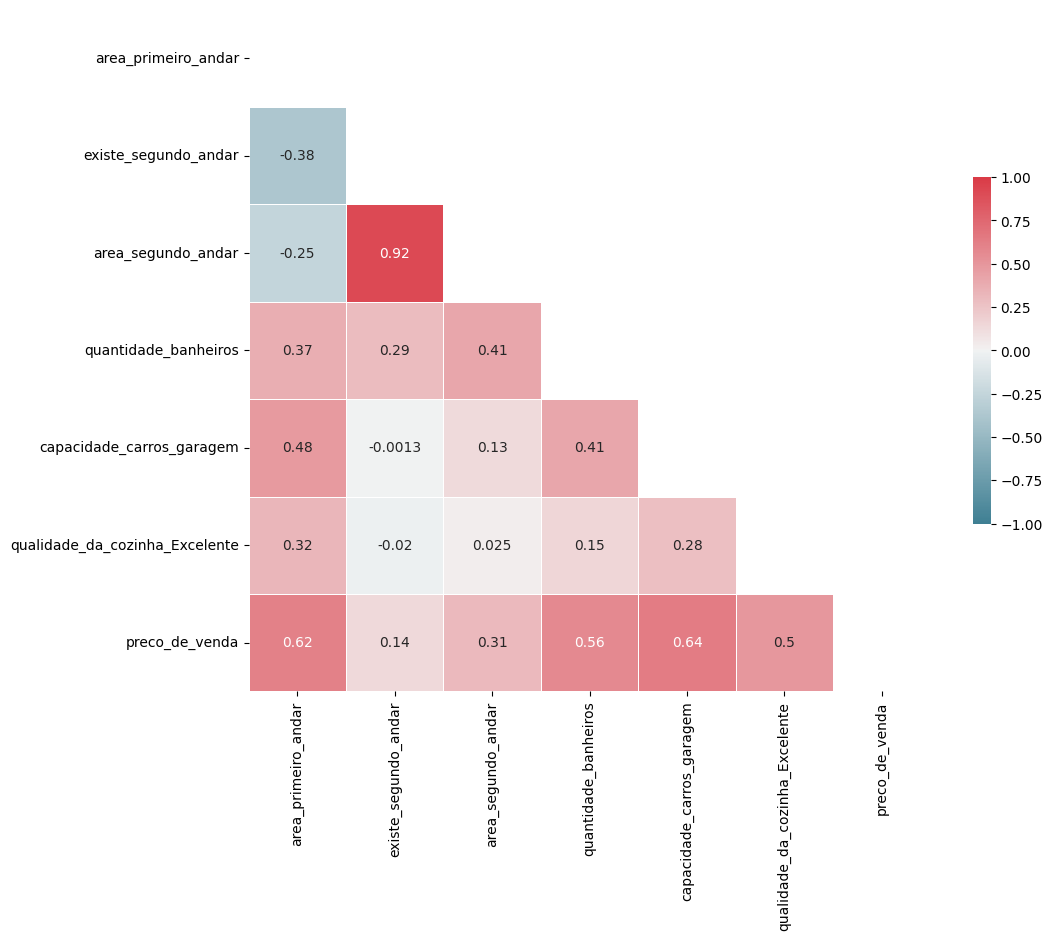

In [7]:
# Atividade
# Quais fatores estão mais correlacionados?
# Atividade
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Quais fatores estão mais correlacionados?

# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()



## Relacionando variáveis

In [8]:
# importando as visualizações

import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Preço da casa')

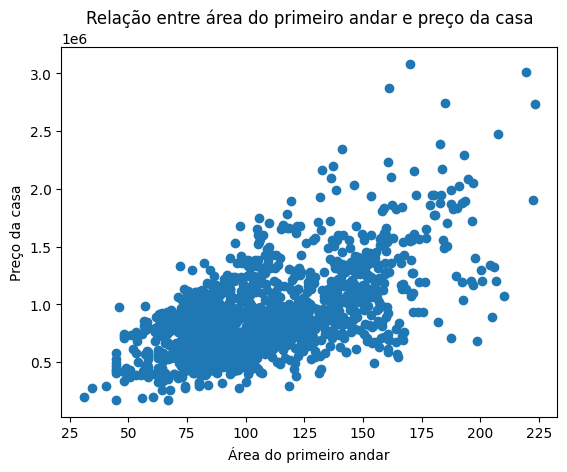

In [9]:
# Como é a relação entre área construida e o preço do imóvel?
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.title('Relação entre área do primeiro andar e preço da casa')
plt.xlabel('Área do primeiro andar')
plt.ylabel('Preço da casa')




Text(0, 0.5, 'Preço da casa')

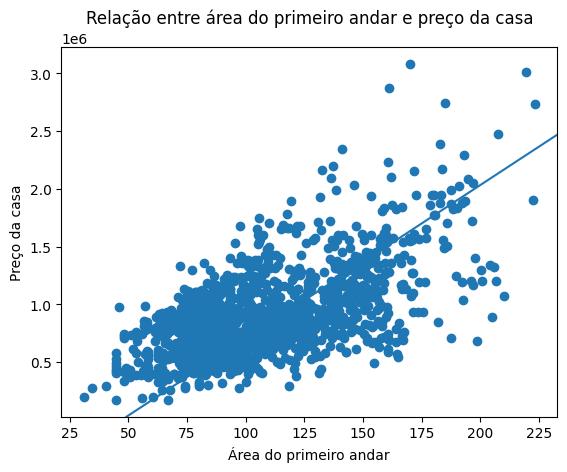

In [10]:
# Aparentemente quanto maior a área do primeiro andar, maior o preço da casa.
# E se quisermos traçar uma linha que melhor representa esse comportamento?
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.axline(xy1 = (66,250000), xy2 = (190,1900000))

plt.title('Relação entre área do primeiro andar e preço da casa')
plt.xlabel('Área do primeiro andar')
plt.ylabel('Preço da casa')





## Melhor reta

In [11]:
# Qual a reta que melhor se adequa a relação?
px.scatter(dados, x = 'area_primeiro_andar', y = 'preco_de_venda', trendline_color_override="red", trendline = 'ols' )

# 2. Explicando a reta
Ajustamos uma reta entre o $m^2$ do primeiro andar e o preço da casa. Queremos explicar o preço da casa a partir do seu tamanho, por isso dizemos que:

* Variável explicativa/independente: Área do primeiro andar

* Variável resposta/dependente: Preço da casa

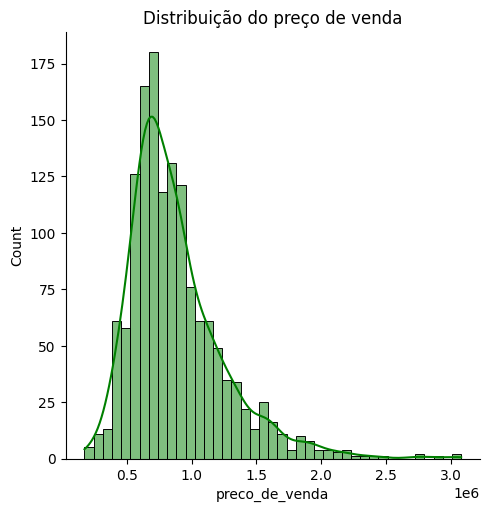

In [12]:
#Quem é nossa variável resposta?

sns.displot(dados['preco_de_venda'], kde=True, color='green')
plt.title('Distribuição do preço de venda')
plt.show()

### Separando em treino e teste

O conjunto de **treinamento** é usado para ajustar o modelo, enquanto o conjunto de **teste** é usado para avaliar seu desempenho em prever preços de casas não vistos durante o treinamento, que auxilia na generalização do modelo.

In [13]:
# import train_test_split
from sklearn.model_selection import train_test_split

In [14]:
# Definindo y e X
y = dados['preco_de_venda']
x = dados.drop(columns='preco_de_venda')

In [102]:
#Aplicando o split do y e X
x_train, x_test,  y_train, y_teste= train_test_split(x,y, test_size=0.3, random_state=200)


In [103]:
#Dados de treino para usar a fórmula
df_train = pd.DataFrame(data = x_train)
df_train['preco_de_venda'] = y_train


In [104]:
# import ols
from statsmodels.formula.api import ols


In [105]:
# ajustando o primeiro modelo
modelo_0 = ols(formula = 'preco_de_venda ~ area_primeiro_andar', data = df_train).fit()


## Analisando os coeficientes

(intensidade, direção e significância)




In [106]:
# visualizando os parametros
modelo_0.params
# area_primeiro_andar indica quanto o valor aumenta conforme aumentamos 1 m2 da área
# intercept sinal + indica correlação,

,0
Intercept,173673.394591
area_primeiro_andar,6558.644152


In [107]:
# o resumo do nosso modelo, indica o efeito
print(modelo_0.summary())


                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     524.4
Date:                Tue, 25 Feb 2025   Prob (F-statistic):           1.04e-93
Time:                        17:45:18   Log-Likelihood:                -14103.
No. Observations:                1006   AIC:                         2.821e+04
Df Residuals:                    1004   BIC:                         2.822e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.737e+05    

* O **intercepto** é o valor esperado do preço da casa quando todas as outras variáveis são zero. Neste caso, quando todas as outras variáveis a área do primeiro andar é zero, o preço esperado da casa é de R$ 145.196,40. Nem sempre temos uma interpretação prática desse número.

* O **efeito individual** da área é 6833.97. Isso indica que para cada 1m² adicinado à área do primero andar espera-se que o preço da casa aumente em média R$6.833,97.

<img src="https://i.imgur.com/7Cm4Cot.png" width="500"/>


## Explicabilidade do modelo

Quanto a variação da área está explicando os diversos preços das casas?

Nesse caso recorremos a métrica R², o coeficiente de determinação. O R² varia de 0 a 1, onde 1 indica um ajuste perfeito do modelo aos dados, ou seja, todas as variações na variável dependente são explicadas pelas variáveis independentes no modelo. Por outro lado, um R² de 0 indica que o modelo não explica nenhuma variabilidade na variável dependente

In [108]:
# observando o R²
modelo_0.rsquared

0.34309920853907994

## Entendendo o resíduo

In [109]:
# Quem são os residuos
modelo_0.resid

,0
1229,-226182.373880
1139,159608.978614
983,105874.571034
866,211553.787715
670,-107387.166427
...,...
1103,-69706.955311
844,207100.291378
810,454599.486504
784,91355.226500


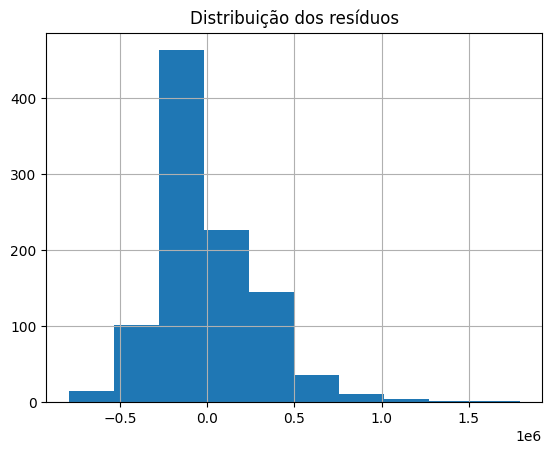

In [110]:
# Como eles estão distribuidos
modelo_0.resid.hist()
plt.title('Distribuição dos resíduos')
plt.show()

![](https://i.imgur.com/CJMdXpf.png)

## Obtendo o R² da previsão

In [111]:
# definindo o Y previsto
y_predict = modelo_0.predict(x_test)

In [112]:
# importando o r2_score
from sklearn.metrics import r2_score

In [113]:
# printando o r²
print("R²: ", r2_score(y_teste,y_predict ))

# o número tem de ser parecido com o outro r2.

R²:  0.45609115885754603


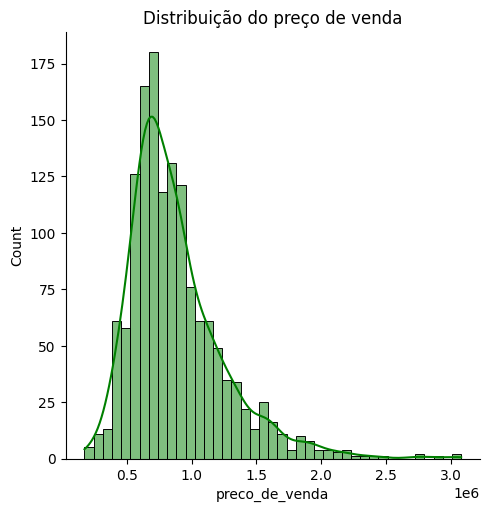

In [114]:
sns.displot(dados['preco_de_venda'], kde=True, color='green')
plt.title('Distribuição do preço de venda')
plt.show()

# 3. Adicionando outras características

O modelo com apenas um fator nos mostrou um R² de 0.37, ou seja, aproximadamente 37% da variação observada nos preços das casas pode ser explicada pela variação na área.
Isso indica que ainda há uma quantidade significativa de variação que não está sendo capturada por esse modelo específico.Vamos analisar outros fatores para explicar o preço das casas.

## Analisando os fatores

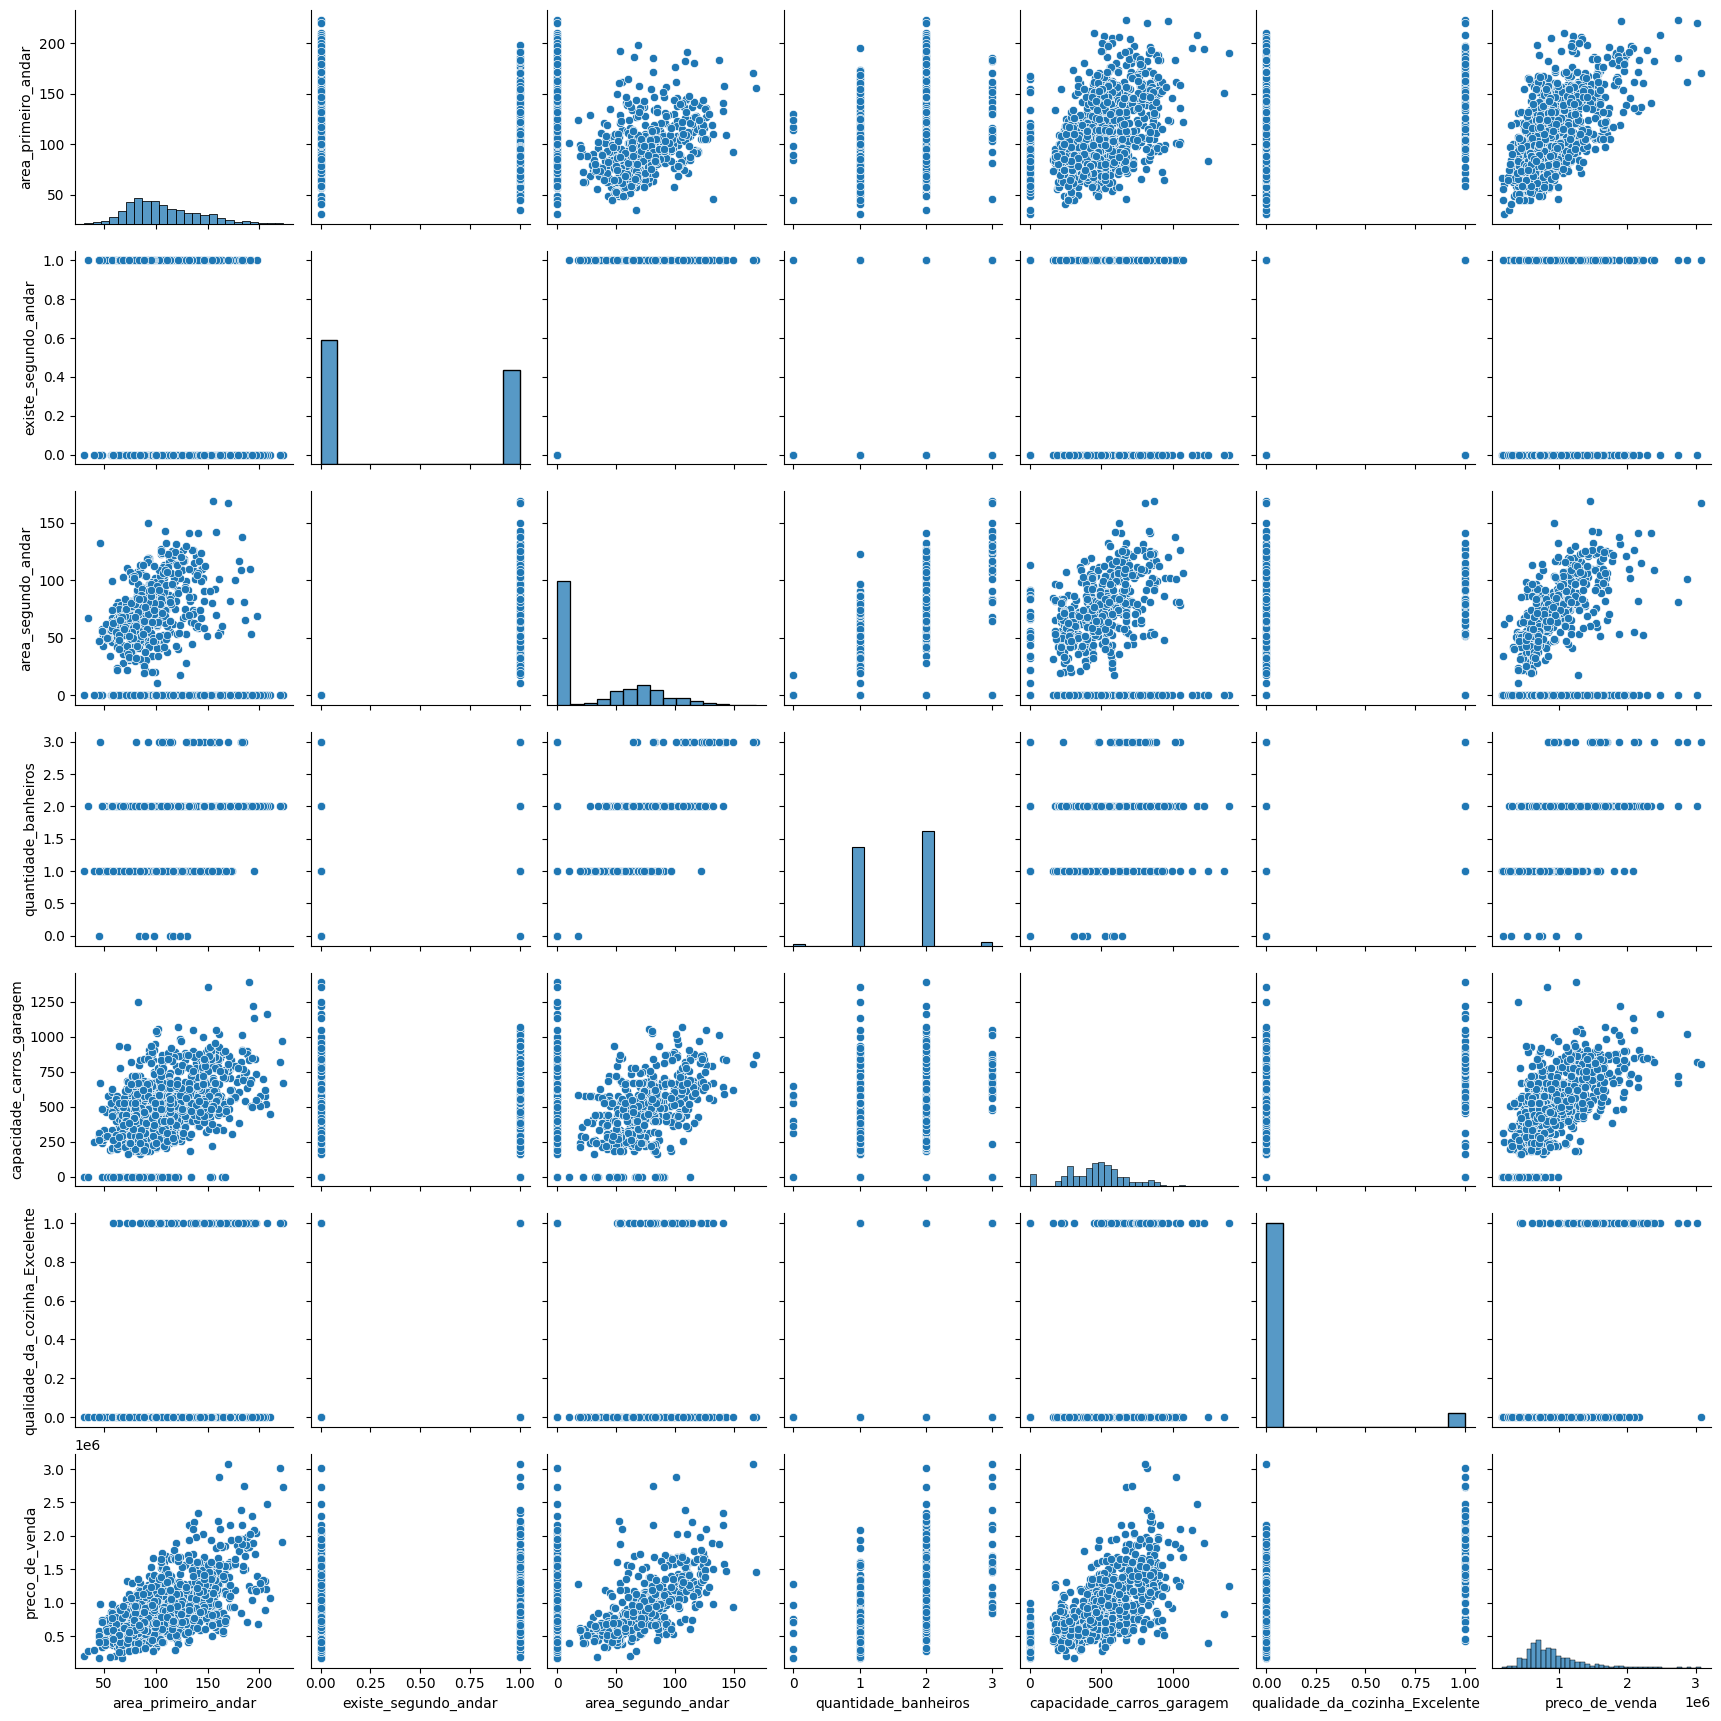

In [115]:
# quais outras características poderiam explicar o preço dos imóveis?
sns.pairplot(dados)

In [116]:
dados.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente', 'preco_de_venda'],
      dtype='object')

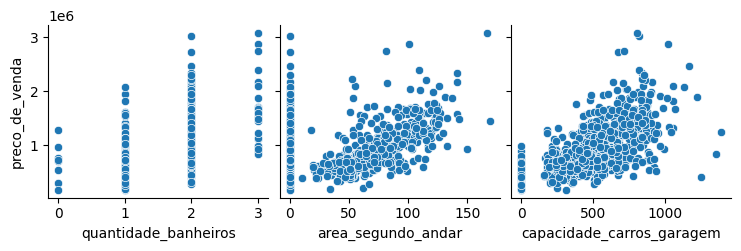

In [117]:
#Vamos olhar apenas com y_vars='preco_de_venda'
sns.pairplot(dados, y_vars = 'preco_de_venda', x_vars = ['quantidade_banheiros','area_segundo_andar','capacidade_carros_garagem'])

## Adicionando fatores no modelo

In [118]:
# importando a api do statsmodels
import statsmodels.api as sm

In [119]:
# adicionando o constante
x_train = sm.add_constant(x_train)


In [120]:
x_train.head()

,const,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente
1229,1.0,105.3486,1,85.8396,1,396,0
1139,1.0,122.0706,0,0.0000,2,626,0
983,1.0,112.2232,0,0.0000,2,632,0
866,1.0,75.0632,1,72.9265,2,389,0
670,1.0,119.9339,0,0.0000,1,431,0


In [121]:
x_train.columns

Index(['const', 'area_primeiro_andar', 'existe_segundo_andar',
       'area_segundo_andar', 'quantidade_banheiros',
       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente'],
      dtype='object')

In [122]:
# Criando o modelo de regressão (sem fómula): saturado
modelo_1 = sm.OLS(y_train,
                  x_train[['const', 'area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar', 'quantidade_banheiros', 'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']]).fit()

In [123]:
# Modelo sem a área do segundo andar
modelo_2 = sm.OLS(y_train,
                  x_train[['const', 'area_primeiro_andar', 'existe_segundo_andar', 'quantidade_banheiros', 'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']]).fit()

In [188]:
# Modelo sem informações sobre garagem
modelo_3 = sm.OLS(y_train,
                  x_train[['const', 'area_primeiro_andar', 'existe_segundo_andar', 'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']]).fit()

In [125]:
# Resumo do modelo 1
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     443.9
Date:                Tue, 25 Feb 2025   Prob (F-statistic):          9.99e-278
Time:                        17:45:47   Log-Likelihood:                -13661.
No. Observations:                1006   AIC:                         2.734e+04
Df Residuals:                     999   BIC:                         2.737e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [126]:
# Resumo do modelo 2
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     445.1
Date:                Tue, 25 Feb 2025   Prob (F-statistic):          2.42e-251
Time:                        17:45:49   Log-Likelihood:                -13726.
No. Observations:                1006   AIC:                         2.746e+04
Df Residuals:                    1000   BIC:                         2.749e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [127]:
# Resumo do modelo 3
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     434.7
Date:                Tue, 25 Feb 2025   Prob (F-statistic):          8.48e-248
Time:                        17:45:50   Log-Likelihood:                -13734.
No. Observations:                1006   AIC:                         2.748e+04
Df Residuals:                    1000   BIC:                         2.751e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## Comparando modelos
Qual o melhor modelo?


In [128]:
print("R²")
print("Modelo 0: ", modelo_0.rsquared)
print("Modelo 1: ", modelo_1.rsquared)
print("Modelo 2: ", modelo_2.rsquared)
print("Modelo 3: ", modelo_3.rsquared)

R²
Modelo 0:  0.34309920853907994
Modelo 1:  0.7272344195556477
Modelo 2:  0.6899743759041395
Modelo 3:  0.6848658912671375


In [129]:
#Quantos parametros estão no modelo?
print(len(modelo_0.params))
print(len(modelo_1.params))
print(len(modelo_2.params))
print(len(modelo_3.params))

2
7
6
6


In [130]:
modelo_3.params

,0
const,10604.929859
area_primeiro_andar,5530.026755
existe_segundo_andar,-200171.936779
area_segundo_andar,5751.226271
quantidade_banheiros,92186.173990
qualidade_da_cozinha_Excelente,466092.653010


# 4. Precificando as casas

## Obtendo o R² da previsão

In [131]:
x_test.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente'],
      dtype='object')

In [177]:
modelo_3.params

,0
const,10604.929859
area_primeiro_andar,5530.026755
existe_segundo_andar,-200171.936779
area_segundo_andar,5751.226271
quantidade_banheiros,92186.173990
qualidade_da_cozinha_Excelente,466092.653010


In [137]:
# Adicionando uma constante em x_test
x_test = sm.add_constant(x_test)

In [189]:
# Prevendo com o modelo_3
predict_3 = modelo_3.predict(x_test[['const', 'area_primeiro_andar',
                   'existe_segundo_andar', 'quantidade_banheiros',
                   'qualidade_da_cozinha_Excelente' ]])

In [190]:
# Qual o R² do treino?
print("R²: ",r2_score(y_teste, predict_3))
# Qual o R² da previsão?
print(modelo_3.rsquared)

R²:  0.6888619406172528
0.6280491913588044


## Precificando uma casa


<img src="https://i.imgur.com/e4gytI1.png" width="800"/>

In [200]:
novo_imovel = pd.DataFrame({'const':[1],
                            'area_primeiro_andar':[98],
                            'existe_segundo_andar': [0],
                            'quantidade_banheiros': [1],
                            'qualidade_da_cozinha_Excelente': [1]
                            })

In [201]:
# Qual o preço desse imóvel com o modelo 0?

modelo_0.predict(novo_imovel['area_primeiro_andar'])

,0
0,816420.521466


In [202]:
# Qual o preço desse imóvel com o modelo 3?
modelo_3.predict(novo_imovel)[0]

1096808.7312702911

## Precificando várias casas

<img src="https://i.imgur.com/i0skFlB.jpeg" width="600"/>

In [197]:
# Lendo várias casas?
novas_casas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science/Dados/Dados regressão linear/Novas_casas.csv', sep=";")
novas_casas.head()
novas_casas = novas_casas.drop(columns = 'Casa')

In [198]:
# Adicionando uma constante
novas_casas = sm.add_constant(novas_casas)


In [199]:
# Qual o preço dessas novas casas?
modelo_3.predict(novas_casas)

,0
0,1.763554e+06
1,1.876361e+06
2,1.590349e+06
3,2.205291e+06
4,1.607828e+06
5,1.223039e+06
6,1.335846e+06
7,1.511713e+06
8,9.518434e+05
9,1.607041e+06


### Salvando o modelo

In [204]:
import pickle

# Nome do arquivo onde o modelo será salvo
nome_arquivo = 'modelo_regressao_linear.pkl'

# Salvar o modelo em um arquivo usando pickle
with open(nome_arquivo, 'wb') as arquivo:
    pickle.dump(modelo_3, arquivo)

In [205]:
# Carregar o modelo de volta do arquivo
with open(nome_arquivo, 'rb') as arquivo:
    modelo_carregado = pickle.load(arquivo)

# 5. Investigando o modelo





## Multicolinearidade


Quando duas ou mais coisas que você está tentando estudar são tão parecidas que é difícil dizer o quanto cada uma delas está influenciando o resultado.

In [54]:
# import do VIF do statsmodel
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [55]:
explicativas_1 = ['const','area_primeiro_andar', 'existe_segundo_andar',
       'area_segundo_andar', 'quantidade_banheiros',
       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']

explicativas_2 = ['const','area_primeiro_andar', 'existe_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente']

explicativas_3 = ['const','area_primeiro_andar', 'existe_segundo_andar',
       'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']

In [212]:
# VIF 1
VIF = pd.DataFrame()
VIF['variavel'] = explicativas_1
VIF['VIF'] = [variance_inflation_factor(x_train[explicativas_1].values, i) for i in range(len(explicativas_1))]
VIF

,variavel,VIF
0,const,20.977356
1,area_primeiro_andar,1.965643
2,existe_segundo_andar,7.222820
3,area_segundo_andar,7.390257
4,quantidade_banheiros,1.654671
5,capacidade_carros_garagem,1.455799
6,qualidade_da_cozinha_Excelente,1.159894


In [213]:
# VIF 3
VIF = pd.DataFrame()
VIF['variavel'] = explicativas_3
VIF['VIF'] = [variance_inflation_factor(x_train[explicativas_3].values, i) for i in range(len(explicativas_3))]
VIF

,variavel,VIF
0,const,18.871599
1,area_primeiro_andar,1.747566
2,existe_segundo_andar,1.564268
3,quantidade_banheiros,1.493972
4,qualidade_da_cozinha_Excelente,1.134412


## Análise dos resíduos

Resíduos: a discrepância entre os valores reais e os valores que o modelo prevê para os mesmos pontos de dados.

In [215]:
# Prevendo os valores do treino X_train[explicativas_3]
y_previsto_train = modelo_3.predict(x_train[explicativas_3])

In [217]:
# Fazendo um scatter plot entre y_previsto e y_train
fig = px.scatter(x=y_previsto_train, y=y_train,
                 title='Previsão X Real',
                 labels={'x':'Preço previsto','y':'Preço real'})
fig.show()

In [219]:
# Residuos
residuos = modelo_3.resid

<Axes: title={'center': 'Resíduos X Previsão'}, xlabel='Preço da Casa - Previsão', ylabel='Resíduos'>

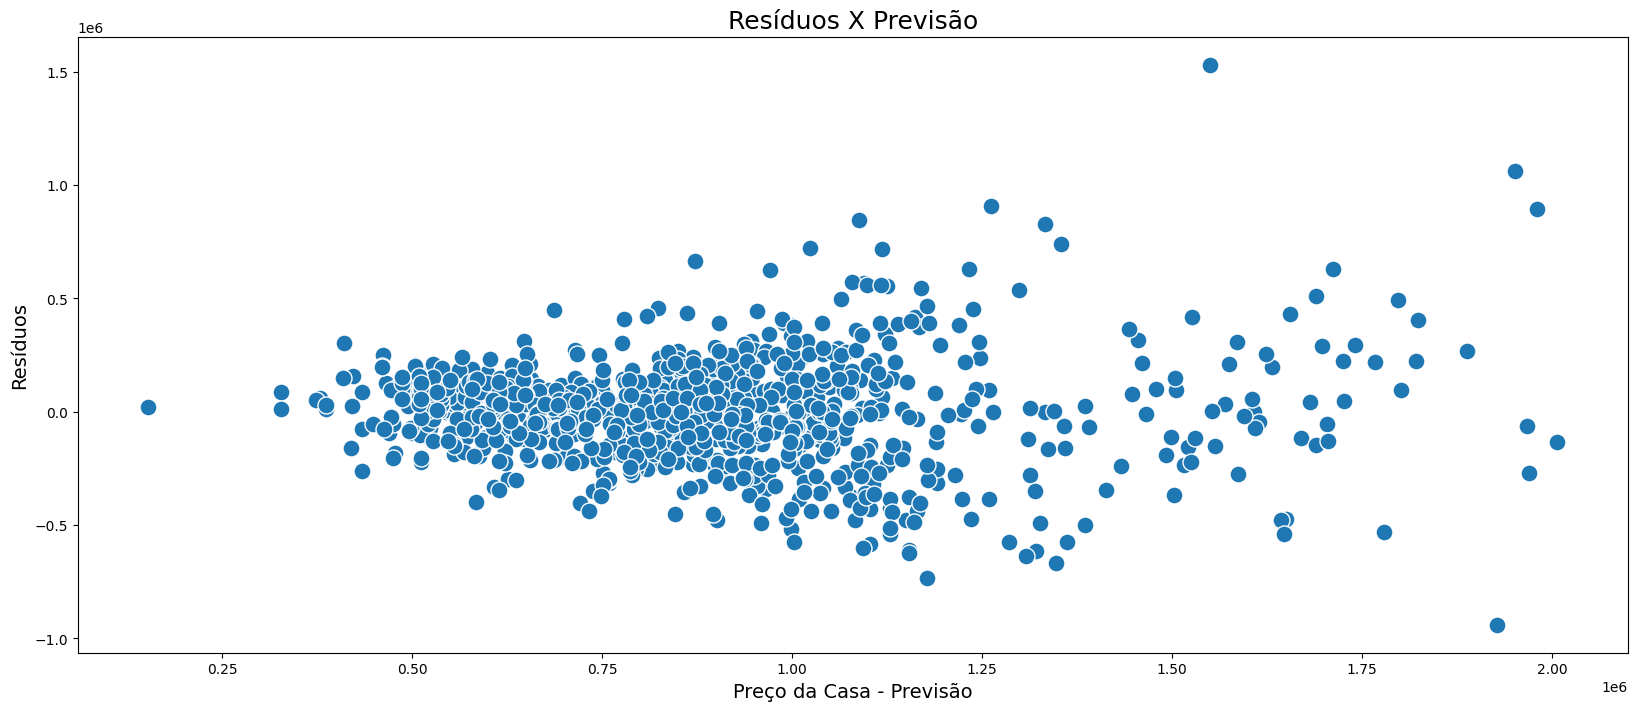

In [220]:
ax = sns.scatterplot(x= y_previsto_train, y=residuos, s=150)
ax.figure.set_size_inches(20, 8)
ax.set_title('Resíduos X Previsão', fontsize=18)
ax.set_xlabel('Preço da Casa - Previsão', fontsize=14)
ax.set_ylabel('Resíduos', fontsize=14)
ax

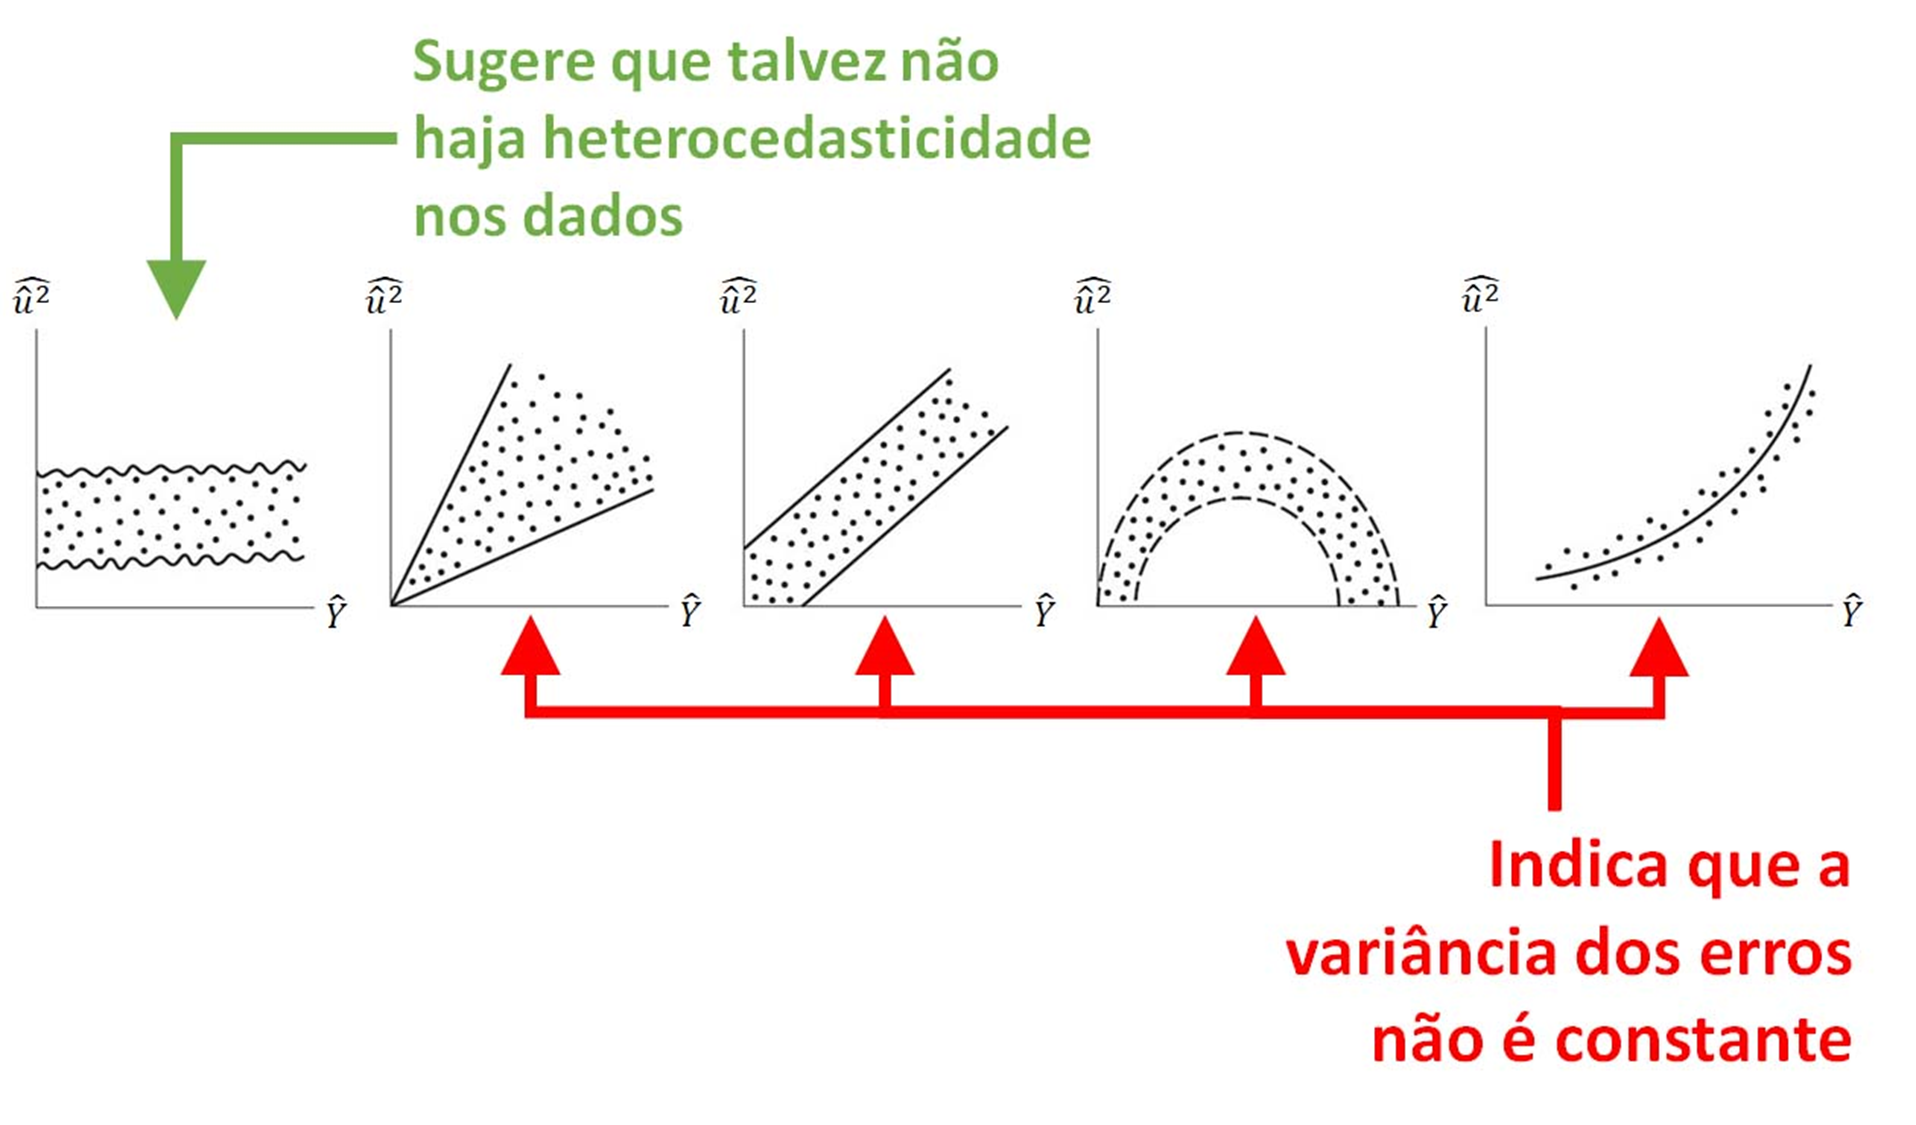

# DESAFIO FINAL DO CURSO

### ETAPAS:
* Primeira etapa: Verifique a multicolinearidade utilizando o conceito de VIF. Se houver indícios de multicolinearidade entre as variáveis, tente pensar em quais medidas podem ser tomadas. Para isso você deverá construir um modelo de regressão linear assumindo que a coluna PE é a variável y.

* Segunda etapa: Realize uma análise de resíduos e identifique se há ou não heterocedasticidade nos dados.

Os resultados obtidos referem-se ao cálculo do Fator de Inflação da Variância (VIF, do inglês Variance Inflation Factor), que é uma métrica usada para quantificar o grau de multicolinearidade em um modelo de regressão linear. O VIF fornece uma indicação de quão muito a variação de um coeficiente de regressão é aumentada devido à multicolinearidade.

Aqui está uma interpretação dos valores de VIF obtidos para cada variável:

1. **const**: Este valor alto (44603.788615) para a constante (intercepto) geralmente não é interpretado no contexto de multicolinearidade, pois é apenas um valor que ajusta a média da resposta quando todas as variáveis preditoras são iguais a zero.

2. **AT (Temperatura ambiente)**: O VIF de aproximadamente 6.03 indica uma multicolinearidade moderada. Um VIF superior a 5 pode ser motivo de preocupação, sugerindo que esta variável tem uma correlação linear moderada com as outras variáveis independentes no modelo.

3. **V (Velocidade do vento)**: Com um VIF de aproximadamente 3.95, indica uma multicolinearidade baixa a moderada. Isso sugere que há alguma correlação com outras variáveis preditivas, mas não é extremamente alta.

4. **AP (Pressão atmosférica)**: O VIF de aproximadamente 1.47 sugere que há pouca multicolinearidade relacionada a esta variável, indicando que ela tem uma relação linear relativamente baixa com as outras variáveis preditoras.

5. **RH (Umidade relativa)**: Um VIF de aproximadamente 1.72 também indica baixa multicolinearidade, mostrando que essa variável tem uma pequena correlação linear com as outras variáveis no modelo.

**Interpretação Geral**:
- Valores de VIF abaixo de 5 geralmente indicam uma multicolinearidade baixa, o que é o caso para AP, V e RH.
- Um VIF entre 5 e 10 (como o visto para AT) sugere uma multicolinearidade moderada, o que pode ou não ser motivo de preocupação, dependendo do contexto específico da análise.
- Valores de VIF acima de 10 indicariam uma multicolinearidade alta, o que não foi observado neste caso, exceto para a constante, que, como mencionado, geralmente não é considerada na análise de multicolinearidade.

Em resumo, os resultados indicam que, exceto pela temperatura ambiente (AT), as outras variáveis têm um nível aceitável de multicolinearidade no modelo. A temperatura ambiente apresenta um nível moderado de multicolinearidade e pode necessitar de uma investigação mais detalhada ou de uma possível reformulação do modelo.

In [234]:
### ETAPA 1

In [239]:
dfusina = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science/Dados/Dados regressão linear/usina.csv')
dfusina.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [240]:
dfusina.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


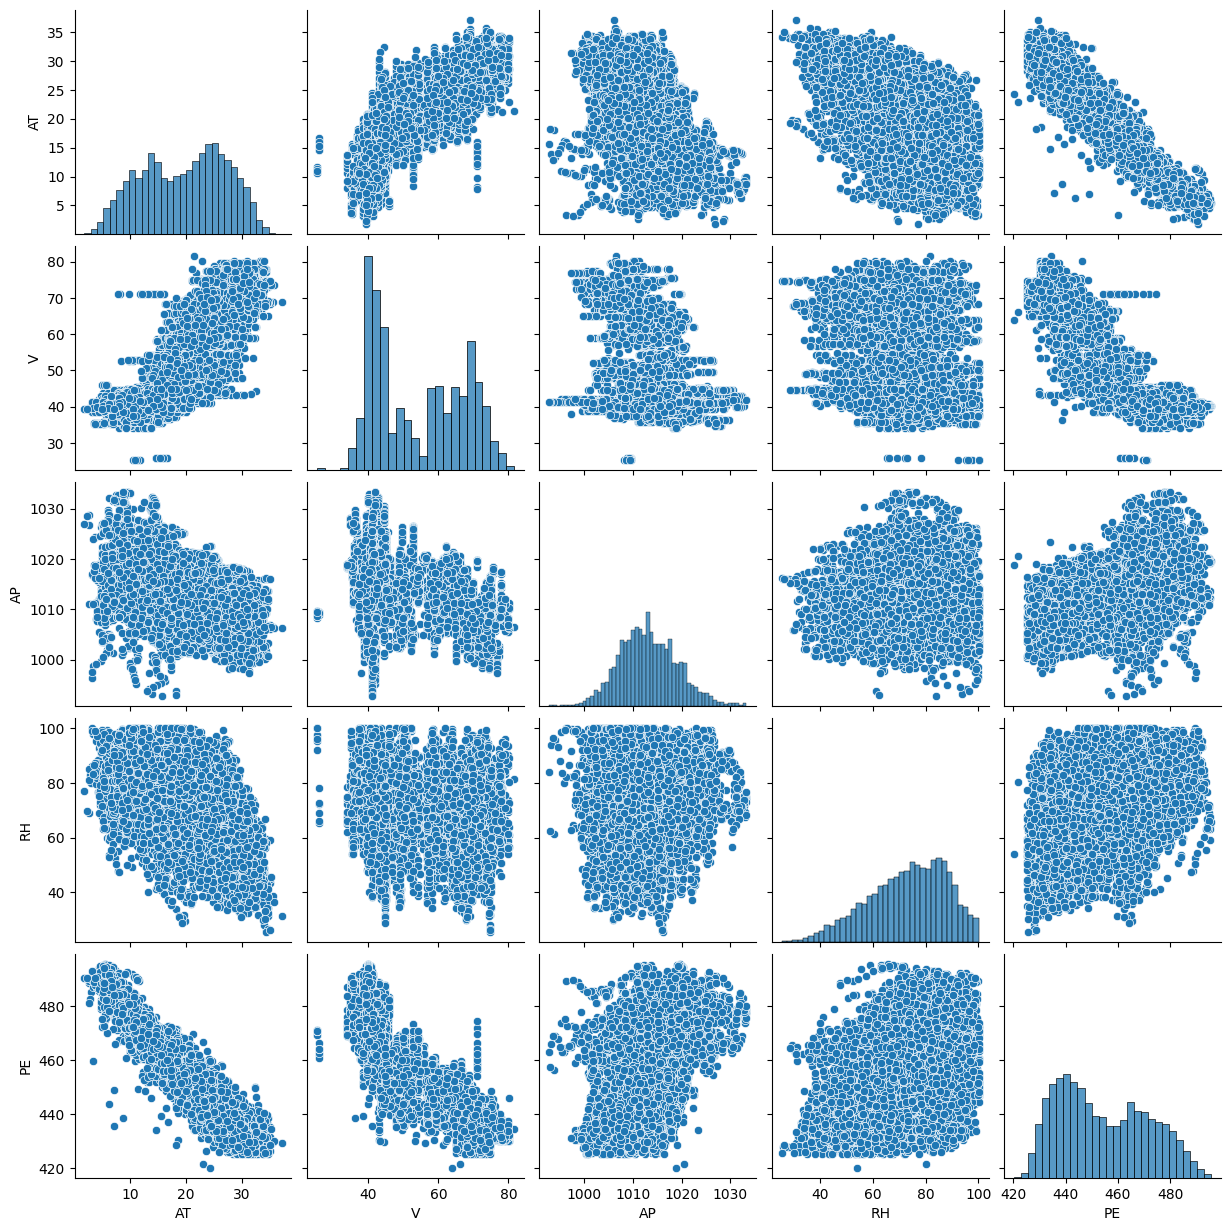

In [241]:
sns.pairplot(dfusina)

In [242]:
from sklearn.model_selection import train_test_split

In [243]:
y = dfusina['PE']
X = dfusina.drop(columns=['PE'])

In [244]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=230)

In [245]:
import statsmodels.api as sm

In [246]:
X_train= sm.add_constant(X_train)

In [247]:
modelo = sm.OLS(y_train,X_train).fit()

In [248]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Tue, 25 Feb 2025   Prob (F-statistic):               0.00
Time:                        18:40:05   Log-Likelihood:                -19662.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.937e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        446.1042     11.769     37.905      0.000     423.033     469.175
AT            -1.9607      0.018   -106.991      0.000      -1.997      -1.925
V             -0.2413      0.009    -27.670      0.000      -0.258      -0.224
AP             0.0702      0.011      6.152      0.000       0.048       0.093
RH            -0.1537      0.005    -30.823      0.000      -0.163      -0.144
==============================================================================
Omnibus:                      481.758   Durbin-Watson:                   1.974
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1740.892
Skew:                          -0.300   Prob(JB):                         0.00
Kurtosis:                       5.424   Cond. No.                     2.15e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.15e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [249]:
### ETAPA 2

In [250]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [253]:
vif_1 = pd.DataFrame()

In [262]:
# prompt: quero calcular o vif do modelo

vif_1["VIF Factor"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_1["features"] = X_train.columns
vif_1

,VIF Factor,features
0,44603.788615,const
1,6.034363,AT
2,3.954998,V
3,1.468530,AP
4,1.717508,RH


In [263]:
import plotly.express as px

In [264]:
y_previsto_train =  modelo.predict(X_train)

In [265]:
fig = px.scatter(x=y_previsto_train, y=y_train,
                 title='Previsão X Real',
                 labels={'x':'Preço previsto','y':'Preço real'})
fig.show()